In [11]:
import pandas as pd
import numpy as np

# Correction : pas d'espace avant l'extension .csv
train_df = pd.read_csv('Data/UNSW_NB15_training-set.csv')
test_df = pd.read_csv('Data/UNSW_NB15_testing-set.csv')

# Suppression de la colonne 'id' si elle existe
train_df.drop(columns=['id'], inplace=True, errors='ignore')
test_df.drop(columns=['id'], inplace=True, errors='ignore')

In [12]:
# 2. ENCODAGE DES VARIABLES CATÉGORIELLES
from sklearn.preprocessing import OneHotEncoder

cat_columns = ['proto', 'service', 'state']


encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
train_encoded = encoder.fit_transform(train_df[cat_columns])
test_encoded = encoder.transform(test_df[cat_columns])


train_encoded_df = pd.DataFrame(train_encoded, columns=encoder.get_feature_names_out(cat_columns))
test_encoded_df = pd.DataFrame(test_encoded, columns=encoder.get_feature_names_out(cat_columns))


train_df = pd.concat([train_df.drop(columns=cat_columns), train_encoded_df], axis=1)
test_df = pd.concat([test_df.drop(columns=cat_columns), test_encoded_df], axis=1)

print(f"Encodage terminé. Nouvelles dimensions : {train_df.shape}")

Encodage terminé. Nouvelles dimensions : (175341, 196)


In [13]:
# 3. NORMALISATION
from sklearn.preprocessing import StandardScaler

# Identifier les colonnes numériques (exclure la cible)
num_columns = [col for col in train_df.columns if col not in ['label', 'attack_cat']]


scaler = StandardScaler()
train_df[num_columns] = scaler.fit_transform(train_df[num_columns])
test_df[num_columns] = scaler.transform(test_df[num_columns])

print("Normalisation terminée")

Normalisation terminée


In [14]:
# 4. SÉPARATION DES FEATURES ET LABELS
X_train = train_df.drop(columns=['label', 'attack_cat'])
y_train = train_df['label'].astype(int)  # Assurer un format correct
X_test = test_df.drop(columns=['label', 'attack_cat'])
y_test = test_df['label'].astype(int)

C:\Users\oumaima\AppData\Local\Temp\ipykernel_18880\1028018136.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='coolwarm')


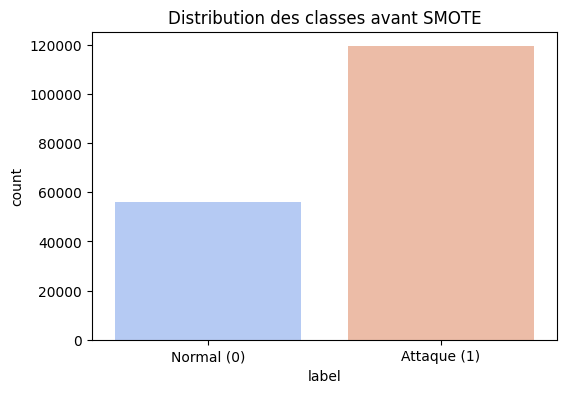

Distribution des classes dans train:
  - Normal (0): 56000 samples
  - Attaque (1): 119341 samples
  - Ratio attaque/normal: 213.11%


In [15]:
# 5. ANALYSE DE LA DISTRIBUTION DES CLASSES
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train, palette='coolwarm')
plt.title("Distribution des classes avant SMOTE")
plt.xticks([0, 1], ['Normal (0)', 'Attaque (1)'])  # Optionnel : ajouter les labels
plt.show()

# Afficher les chiffres exacts
print(f"Distribution des classes dans train:")
print(f"  - Normal (0): {(y_train == 0).sum()} samples")
print(f"  - Attaque (1): {(y_train == 1).sum()} samples")
print(f"  - Ratio attaque/normal: {(y_train == 1).sum() / (y_train == 0).sum():.2%}")

C:\Users\oumaima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
C:\Users\oumaima\AppData\Local\Temp\ipykernel_18880\2870626501.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_resampled, palette='coolwarm')


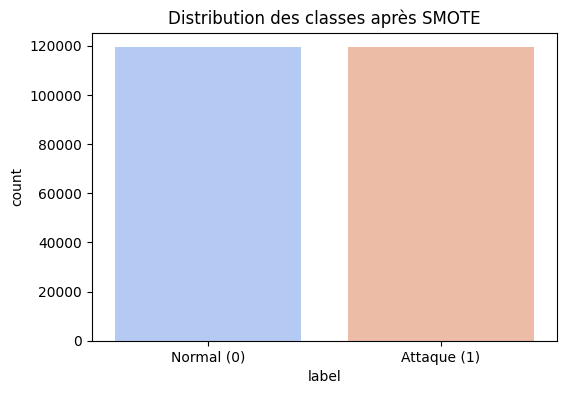

Distribution des classes après SMOTE:
  - Normal (0): 119341 samples
  - Attaque (1): 119341 samples
  - Ratio: 100.00%


In [16]:
# 6. APPLICATION DE SMOTE POUR EQUILIBRER LES CLASSES
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

plt.figure(figsize=(6, 4))
sns.countplot(x=y_train_resampled, palette='coolwarm')
plt.title("Distribution des classes après SMOTE")
plt.xticks([0, 1], ['Normal (0)', 'Attaque (1)'])
plt.show()

# Afficher la nouvelle distribution
print(f"Distribution des classes après SMOTE:")
print(f"  - Normal (0): {(y_train_resampled == 0).sum()} samples")
print(f"  - Attaque (1): {(y_train_resampled == 1).sum()} samples")
print(f"  - Ratio: {(y_train_resampled == 1).sum() / (y_train_resampled == 0).sum():.2%}")

In [17]:
# 7. RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test) 
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.885330126803673


Entraînement autoencodeur sur 119341 échantillons normaux uniquement


C:\Users\oumaima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0488 - val_loss: 0.4695
Epoch 2/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0032 - val_loss: 0.4669
Epoch 3/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0021 - val_loss: 0.4649
Epoch 4/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0015 - val_loss: 0.4644
Epoch 5/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0013 - val_loss: 0.4643
Epoch 6/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 9.5845e-04 - val_loss: 0.4644
Epoch 7/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 8.6527e-04 - val_loss: 0.4644
Epoch 8/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 7.8260e-04 - val_loss: 0.4644
Epoch 9/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 7.3313e-04 - val_loss: 0.4645
Epoch 10/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 6.8548e-04 - val_loss: 0.4643
Epoch 11/50
467/467 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 6.5010e-04 - val_loss: 0.4645
Epoch 12/50
467/467 ━━━━━

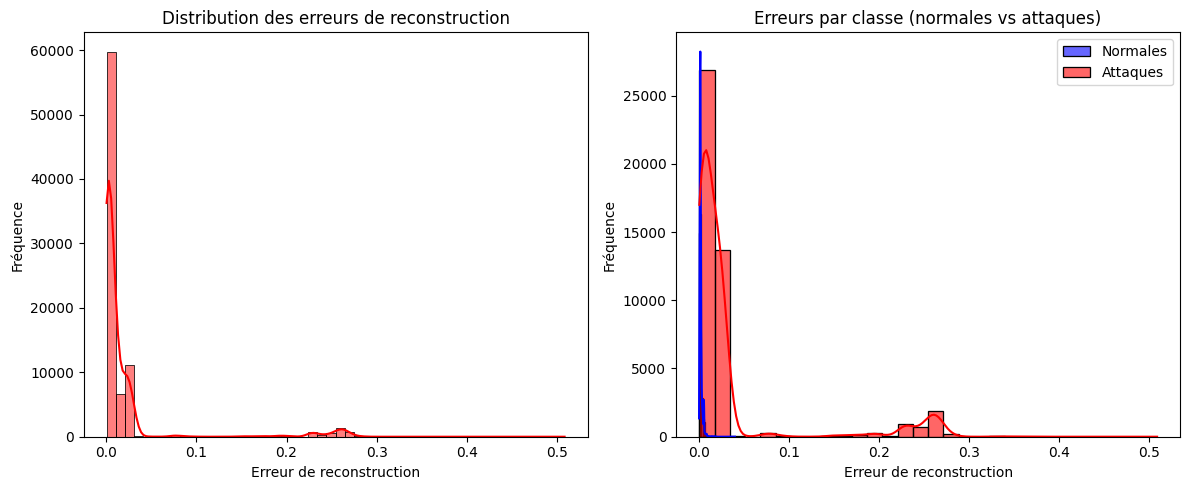


Erreur moyenne sur les normales: 0.0022
Erreur moyenne sur les attaques: 0.0351
Différence: 0.0329

Score autoencodeur (normalisé) - Moyenne: 0.039


In [18]:
# 8. AUTOENCODEUR 
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam



# Filtrer pour ne garder que les échantillons normaux (label = 0)
X_train_normal = X_train_resampled[y_train_resampled == 0] 
print(f"Entraînement autoencodeur sur {X_train_normal.shape[0]} échantillons normaux uniquement")

# Normalisation
scaler_ae = MinMaxScaler()
X_train_normal_scaled = scaler_ae.fit_transform(X_train_normal)  # ← Entraînement sur normales
X_test_scaled = scaler_ae.transform(X_test)  # ← Test sur TOUTES les données (normales + attaques)

input_dim = X_train_normal_scaled.shape[1]

# Architecture de l'autoencodeur
autoencoder = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(input_dim, activation='sigmoid')  
])

autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Entraîner sur X_train_normal_scaled (pas sur tout X_train)
autoencoder.fit(
    X_train_normal_scaled,  # ← Données d'entrée : NORMALES
    X_train_normal_scaled,  # ← Cibles : NORMALES (reconstruction auto)
    epochs=50, 
    batch_size=256, 
    validation_data=(X_test_scaled, X_test_scaled),  # ← Validation sur tout le test
    verbose=1
)

# Visualisation des erreurs de reconstruction 
reconstruction_error = np.mean(np.abs(autoencoder.predict(X_test_scaled) - X_test_scaled), axis=1)

# Visualisation 
plt.figure(figsize=(12, 5))

# Graphique 1 : Distribution globale
plt.subplot(1, 2, 1)
sns.histplot(reconstruction_error, bins=50, kde=True, color='red')
plt.title("Distribution des erreurs de reconstruction")
plt.xlabel("Erreur de reconstruction")
plt.ylabel("Fréquence")

# Graphique 2 : Séparation normales vs attaques pour vérification
plt.subplot(1, 2, 2)
error_normal = reconstruction_error[y_test == 0]
error_attack = reconstruction_error[y_test == 1]
sns.histplot(error_normal, bins=30, kde=True, color='blue', label='Normales', alpha=0.6)
sns.histplot(error_attack, bins=30, kde=True, color='red', label='Attaques', alpha=0.6)
plt.title("Erreurs par classe (normales vs attaques)")
plt.xlabel("Erreur de reconstruction")
plt.ylabel("Fréquence")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nErreur moyenne sur les normales: {error_normal.mean():.4f}")
print(f"Erreur moyenne sur les attaques: {error_attack.mean():.4f}")
print(f"Différence: {error_attack.mean() - error_normal.mean():.4f}")

# Maintenant l'autoencodeur est utile, on peut le réintégrer dans la fusion
ae_preds_normalized = (reconstruction_error - reconstruction_error.min()) / (reconstruction_error.max() - reconstruction_error.min())
print(f"\nScore autoencodeur (normalisé) - Moyenne: {ae_preds_normalized.mean():.3f}")

In [19]:
# 9. CNN-LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Flatten, Dense

# Reshape pour CNN-LSTM (samples, timesteps, features)
X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_seq = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Forme X_train_seq: {X_train_seq.shape}")
print(f"Forme X_test_seq: {X_test_seq.shape}")

cnn_lstm = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_seq.shape[1], 1)),
    LSTM(50, return_sequences=False),  # Correction: return_sequences=False pour éviter la sortie 3D
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1, activation='sigmoid')
])  

cnn_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn_lstm.fit(X_train_seq, y_train_resampled, epochs=10, batch_size=64, validation_data=(X_test_seq, y_test))  

Forme X_train_seq: (238682, 194, 1)
Forme X_test_seq: (82332, 194, 1)


C:\Users\oumaima\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 676s 180ms/step - accuracy: 0.7622 - loss: 0.4695 - val_accuracy: 0.7900 - val_loss: 0.4160
Epoch 2/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 715s 192ms/step - accuracy: 0.8015 - loss: 0.4138 - val_accuracy: 0.7794 - val_loss: 0.3959
Epoch 3/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 486s 130ms/step - accuracy: 0.8902 - loss: 0.2048 - val_accuracy: 0.7855 - val_loss: 0.3695
Epoch 4/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 465s 125ms/step - accuracy: 0.8927 - loss: 0.2010 - val_accuracy: 0.7473 - val_loss: 0.4850
Epoch 5/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 316s 85ms/step - accuracy: 0.8009 - loss: 0.3977 - val_accuracy: 0.7879 - val_loss: 0.3707
Epoch 6/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 1243s 333ms/step - accuracy: 0.8949 - loss: 0.1906 - val_accuracy: 0.7845 - val_loss: 0.3912
Epoch 7/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 279s 75ms/step - accuracy: 0.8914 - loss: 0.1995 - val_accuracy: 0.7864 - val_loss: 0.4175
Epoch 8/10
3730/3730 ━━━━━━━━━━━━━━━━━━━━ 295s 79ms/step - accu

2573/2573 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step

📊 Résultats de la fusion:
Random Forest (poids 0.5) - Moyenne: 0.627
Autoencodeur (poids 0.3) - Moyenne: 0.020
CNN-LSTM (poids 0.2) - Moyenne: 0.580

📈 Classification Report Final:
              precision    recall  f1-score   support

  Normal (0)       0.89      0.91      0.90     37000
 Attaque (1)       0.92      0.91      0.92     45332

    accuracy                           0.91     82332
   macro avg       0.91      0.91      0.91     82332
weighted avg       0.91      0.91      0.91     82332



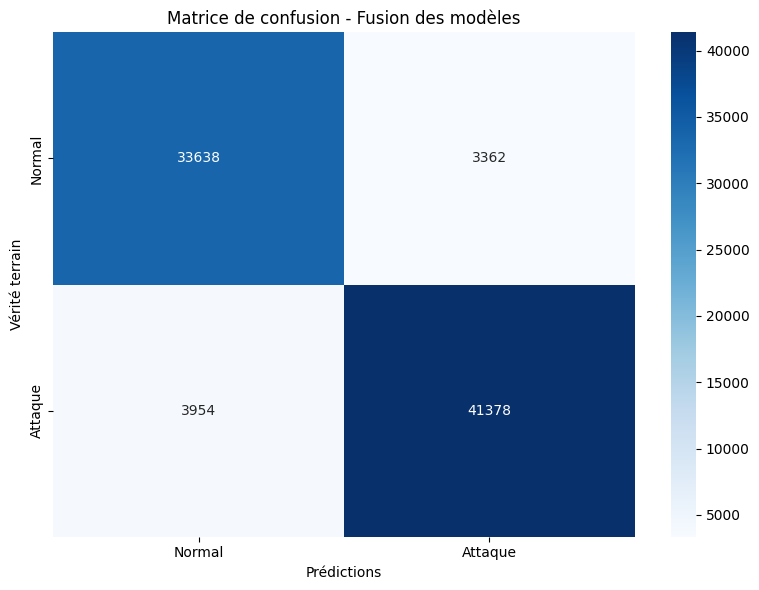


✅ Accuracy finale du modèle fusionné: 0.9111 (91.11%)


In [20]:
from sklearn.metrics import classification_report, confusion_matrix

rf_preds = rf_model.predict_proba(X_test)[:, 1]
ae_preds = reconstruction_error
cnn_lstm_preds = cnn_lstm.predict(X_test_seq).flatten()

# Fusion pondérée des prédictions
final_preds = (rf_preds * 0.5) + (ae_preds * 0.3) + (cnn_lstm_preds * 0.2)
final_labels = (final_preds > 0.5).astype(int)

print("\n📊 Résultats de la fusion:")
print(f"Random Forest (poids 0.5) - Moyenne: {rf_preds.mean():.3f}")
print(f"Autoencodeur (poids 0.3) - Moyenne: {ae_preds.mean():.3f}")
print(f"CNN-LSTM (poids 0.2) - Moyenne: {cnn_lstm_preds.mean():.3f}")

print("\n📈 Classification Report Final:")
print(classification_report(y_test, final_labels, target_names=['Normal (0)', 'Attaque (1)']))

# Matrice de confusion sous forme de heatmap
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, final_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attaque'], 
            yticklabels=['Normal', 'Attaque'])
plt.xlabel("Prédictions")
plt.ylabel("Vérité terrain")
plt.title("Matrice de confusion - Fusion des modèles")
plt.tight_layout()
plt.show()

# Calcul de l'accuracy finale
from sklearn.metrics import accuracy_score
final_accuracy = accuracy_score(y_test, final_labels)
print(f"\n✅ Accuracy finale du modèle fusionné: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)")